In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sro_sto_plume import microscopy as mic


# Batch Roughness Comparison Across Area Exports

This notebook loads the full-area height maps exported as TXT files, flattens them (optional), and reports roughness in two ways:

1. Treat every pixel across all images in a folder as a single surface and compute Ra/Rq/Rz.
2. Compute the mean height of each image, then evaluate the variation of those means (image-to-image roughness).

Update the configuration below to point at the folders you would like to compare.

In [2]:
# --- Configuration ---
DATA_FOLDERS = [
    {"name": "G1", "path": Path("../data/TargetMicroscopy/Scan2/G1/"),  "loader": "txt", "pattern": "*.txt"},
    {"name": "G2", "path": Path("../data/TargetMicroscopy/Scan2/G2/"),   "loader": "txt",
     "pattern": "*.txt"},
    {"name": "G3", "path": Path("../data/TargetMicroscopy/Scan2/G3/"),   "loader": "txt",
     "pattern": "*.txt"},
]
PATTERN = "*.txt"           # default glob pattern
DETREND = False               # remove best-fit plane before computing roughness
ZERO_CENTER = False           # subtract per-image mean (after detrend)
HEIGHT_SCALE = 1e6           # meters -> micrometers
HEIGHT_UNIT = "µm"

In [3]:
def analyze_area_folder(folder_path: Path,
                          name: str | None = None,
                          *,
                          pattern: str = "*.txt",
                          loader: str = "txt",
                          dataset_keyword: str = "Surface",
                          detrend: bool = False,
                          zero_center: bool = False,
                          scale: float = 1.0,
                          unit: str = "µm"):
    """Compute batch roughness metrics for all height maps in a folder."""

    folder_path = Path(folder_path)
    files = sorted(folder_path.glob(pattern))
    if not files:
        raise ValueError(f"No files matching {pattern!r} in {folder_path}")

    loader_lower = loader.lower()
    if loader_lower == "txt":
        batch = mic.batch_roughness_from_txt(files, detrend=detrend, zero_center=zero_center)
    elif loader_lower == "datx":
        batch = mic.batch_roughness_from_datx(files,
                                             dataset_keyword=dataset_keyword,
                                             detrend=detrend,
                                             zero_center=zero_center)
    else:
        raise ValueError(f"Unsupported loader '{loader}'. Use 'txt' or 'datx'.")

    def scale_record(record: dict[str, float]) -> dict[str, float]:
        rec = record.copy()
        for key in ("mean", "Ra", "Rq", "Rz"):
            rec[key] = rec[key] * scale
        return rec

    folder_label = name or folder_path.name

    global_stats = scale_record(batch["global_pixels"])
    global_stats.update({
        "folder": folder_label,
        "n_images": len(batch["per_image"]),
        "count": batch["global_pixels"]["count"],
        "detrended": detrend,
        "zero_center": zero_center,
        "unit": unit,
    })

    mean_stats = scale_record(batch["image_mean_variation"])
    mean_stats.update({
        "folder": folder_label,
        "count": batch["image_mean_variation"]["count"],
        "detrended": detrend,
        "zero_center": zero_center,
        "unit": unit,
    })

    per_image_rows = []
    for file, record in zip(files, batch["per_image"]):
        scaled = scale_record(record)
        scaled.update({
            "folder": folder_label,
            "path": str(file),
            "count": record["count"],
            "detrended": detrend,
            "zero_center": zero_center,
            "unit": unit,
        })
        per_image_rows.append(scaled)

    per_image_df = pd.DataFrame(per_image_rows)

    return global_stats, mean_stats, per_image_df



## Compute batch roughness statistics

For each folder, the code below:

- loads all TXT files matching `PATTERN`,
- optionally detrends each map,
- records per-image roughness metrics,
- aggregates across all pixels,
- computes image-to-image variation (based on the mean height per image).

In [4]:
folder_summaries = []
mean_summaries = []
per_image_frames = []

for entry in DATA_FOLDERS:
    folder_name = entry["name"]
    folder_path = entry["path"]
    loader = entry.get("loader", "txt")
    dataset_keyword = entry.get("dataset_keyword", "Surface")
    pattern = entry.get("pattern", PATTERN)

    try:
        global_stats, mean_stats, per_image_df = analyze_area_folder(
            folder_path,
            name=folder_name,
            pattern=pattern,
            loader=loader,
            dataset_keyword=dataset_keyword,
            detrend=DETREND,
            zero_center=ZERO_CENTER,
            scale=HEIGHT_SCALE,
            unit=HEIGHT_UNIT,
        )
    except ValueError as exc:
        print(f"[WARN] {exc}")
        continue

    folder_summaries.append(global_stats)
    mean_summaries.append(mean_stats)
    per_image_frames.append(per_image_df)

if not folder_summaries:
    raise ValueError("No folders produced data. Check DATA_FOLDERS and PATTERN.")

folder_df = pd.DataFrame(folder_summaries).set_index("folder")
mean_df = pd.DataFrame(mean_summaries).set_index("folder")
per_image_df = pd.concat(per_image_frames, ignore_index=True)

print("Global pixel-wise roughness (all pixels pooled)")
display(folder_df[["mean", "Ra", "Rq", "Rz", "count", "n_images", "detrended", "zero_center", "unit"]])

print("Image-to-image variation (based on image means)")
display(mean_df[["mean", "Ra", "Rq", "Rz", "count", "detrended", "zero_center", "unit"]])

print("Per-image roughness metrics")
display(per_image_df[["folder", "path", "mean", "Ra", "Rq", "Rz", "count", "detrended", "zero_center", "unit"]])



Global pixel-wise roughness (all pixels pooled)


,mean,Ra,Rq,Rz,count,n_images,detrended,zero_center,unit
folder,,,,,,,,,
G1,-1.351992e-08,2.414951,3.171569,110.563,3145728,3,False,False,µm
G2,-1.797314e-08,2.577407,3.353147,118.984,3145728,3,False,False,µm
G3,-4.689830e-08,3.057617,3.889233,114.028,3145728,3,False,False,µm


Image-to-image variation (based on image means)


,mean,Ra,Rq,Rz,count,detrended,zero_center,unit
folder,,,,,,,,
G1,-1.351992e-08,1.197321e-08,1.291131e-08,2.979224e-08,3,False,False,µm
G2,-1.797314e-08,1.494202e-08,1.765642e-08,4.315190e-08,3,False,False,µm
G3,-4.689830e-08,5.457531e-09,6.610787e-09,1.618997e-08,3,False,False,µm


Per-image roughness metrics


,folder,path,mean,Ra,Rq,Rz,count,detrended,zero_center,unit
0,G1,../data/TargetMicroscopy/Scan2/G1/Area0.txt,-2.535235e-08,2.196678,2.900505,100.347,1048576,False,False,µm
1,G1,../data/TargetMicroscopy/Scan2/G1/Area1.txt,4.439895e-09,2.291118,2.886715,98.843,1048576,False,False,µm
2,G1,../data/TargetMicroscopy/Scan2/G1/Area2.txt,-1.964731e-08,2.757056,3.664765,94.561,1048576,False,False,µm
3,G2,../data/TargetMicroscopy/Scan2/G2/Area1.txt,4.439895e-09,2.291118,2.886715,98.843,1048576,False,False,µm
4,G2,../data/TargetMicroscopy/Scan2/G2/Area2.txt,-1.964731e-08,2.757056,3.664765,94.561,1048576,False,False,µm
5,G2,../data/TargetMicroscopy/Scan2/G2/Area3.txt,-3.871200e-08,2.684048,3.459358,101.394,1048576,False,False,µm
6,G3,../data/TargetMicroscopy/Scan2/G3/Area3.txt,-3.871200e-08,2.684048,3.459358,101.394,1048576,False,False,µm
7,G3,../data/TargetMicroscopy/Scan2/G3/Area4.txt,-5.490197e-08,3.539085,4.408848,99.088,1048576,False,False,µm
8,G3,../data/TargetMicroscopy/Scan2/G3/Area5.txt,-4.708092e-08,2.949719,3.738088,99.547,1048576,False,False,µm


## Visual comparisons

Bar plots and strip plots make it easier to compare roughness across folders.

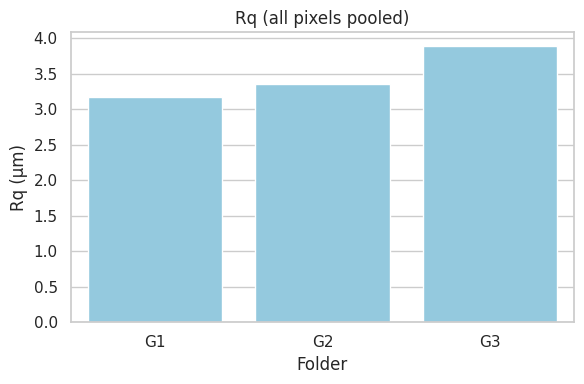

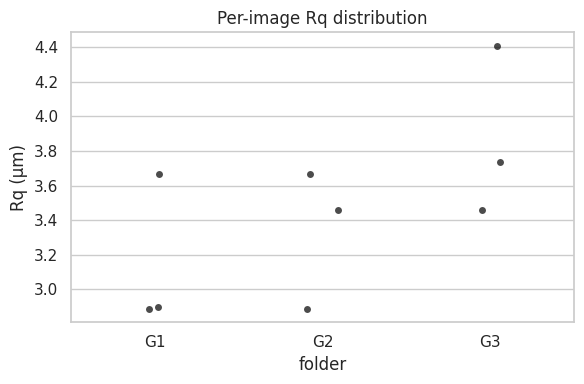

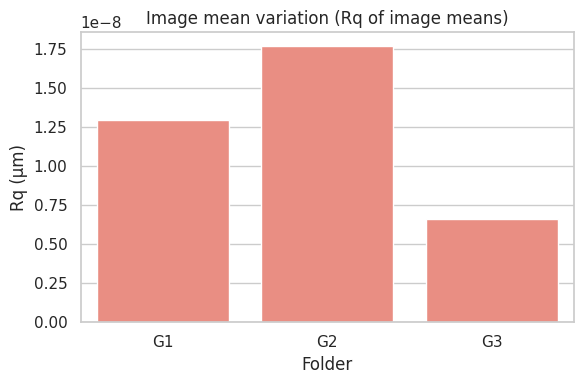

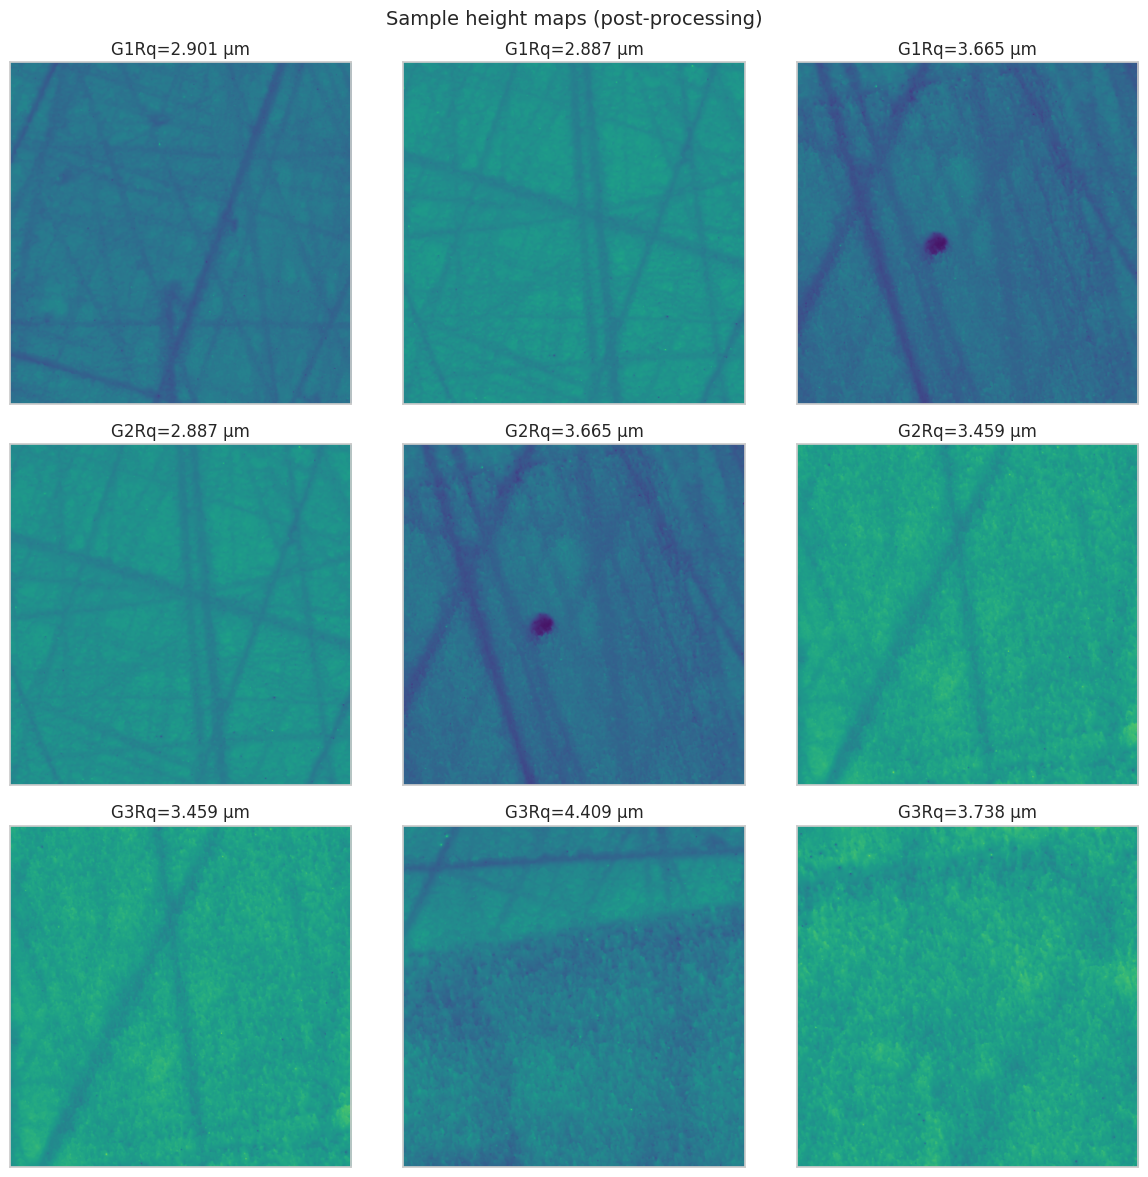

In [5]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(max(6, len(folder_df) * 1.0), 4))
sns.barplot(x=folder_df.index, y="Rq", data=folder_df.reset_index(), ax=ax, color="skyblue")
ax.set_ylabel(f"Rq ({HEIGHT_UNIT})")
ax.set_xlabel("Folder")
ax.set_title("Rq (all pixels pooled)")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(max(6, len(per_image_df) * 0.6), 4))
sns.stripplot(data=per_image_df, x="folder", y="Rq", ax=ax, color="black", alpha=0.7)
ax.set_ylabel(f"Rq ({HEIGHT_UNIT})")
ax.set_title("Per-image Rq distribution")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(max(6, len(mean_df) * 1.0), 4))
sns.barplot(x=mean_df.index, y="Rq", data=mean_df.reset_index(), ax=ax, color="salmon")
ax.set_ylabel(f"Rq ({HEIGHT_UNIT})")
ax.set_xlabel("Folder")
ax.set_title("Image mean variation (Rq of image means)")
fig.tight_layout()
plt.show()

# Thumbnail visualization
n_images = len(per_image_df)
if n_images:
    ncols = min(3, n_images)
    nrows = int(np.ceil(n_images / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax in axes[n_images:]:
        ax.axis('off')

    for ax, row in zip(axes, per_image_df.itertuples()):
        path = Path(row.path)
        loader = next((entry.get('loader', 'txt').lower() for entry in DATA_FOLDERS
                       if entry['name'] == row.folder), 'txt')

        if loader == 'datx':
            data = mic.load_datx_height_map(path)
        else:
            data = mic.load_height_txt(path)

        if DETREND:
            data = mic._detrend_plane(data)
        if ZERO_CENTER:
            mean_val = np.nanmean(data)
            if np.isfinite(mean_val):
                data = data - mean_val

        ax.imshow(data, cmap='viridis')
        ax.set_title(f"{row.folder}Rq={row.Rq:.3f} {HEIGHT_UNIT}")
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle('Sample height maps (post-processing)', fontsize=14)
    fig.tight_layout()

plt.show()

